## Loss is a numerical metric that describes how wrong a model's predictions are. Loss measures the distance between the model's predictions and the actual labels. The goal of training a model is to minimize the loss, reducing it to its lowest possible value.

## In statistics and machine learning, loss measures the difference between the predicted and actual values. Loss focuses on the distance between the values, not the direction. For example, if a model predicts 2, but the actual value is 5, we don't care that the loss is negative (2 – 5= –3). Instead, we care that the distance between the values is 3. Thus, all methods for calculating loss remove the sign.

The two most common methods to remove the sign are the following:

Take the absolute value of the difference between the actual value and the prediction.
Square the difference between the actual value and the prediction.

	
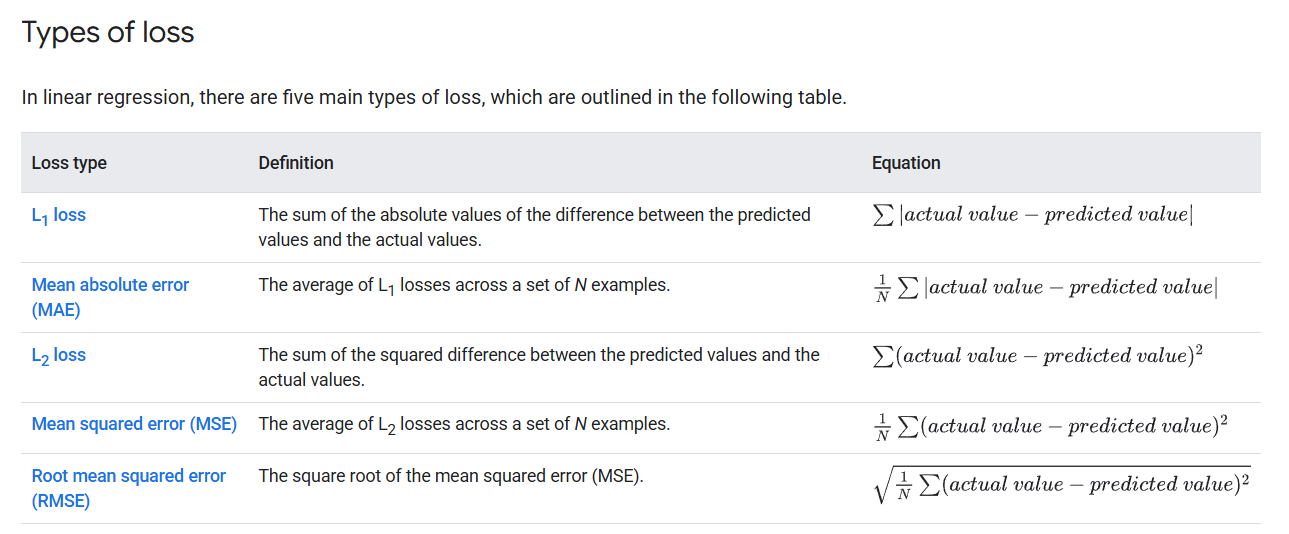

## An outlier can also refer to how far off a model's predictions are from the real values. For instance, 3,000 pounds is within the typical car-weight range, and 40 miles per gallon is within the typical fuel-efficiency range. However, a 3,000-pound car that gets 40 miles per gallon would be an outlier in terms of the model's prediction because the model would predict that a 3,000-pound car would get around 20 miles per gallon.

When choosing the best loss function, consider how you want the model to treat outliers. For instance, MSE moves the model more toward the outliers, while MAE doesn't. L2 loss incurs a much higher penalty for an outlier than L1 loss. For example, the following images show a model trained using MAE and a model trained using MSE. The red line represents a fully trained model that will be used to make predictions. The outliers are closer to the model trained with MSE than to the model trained with MAE.

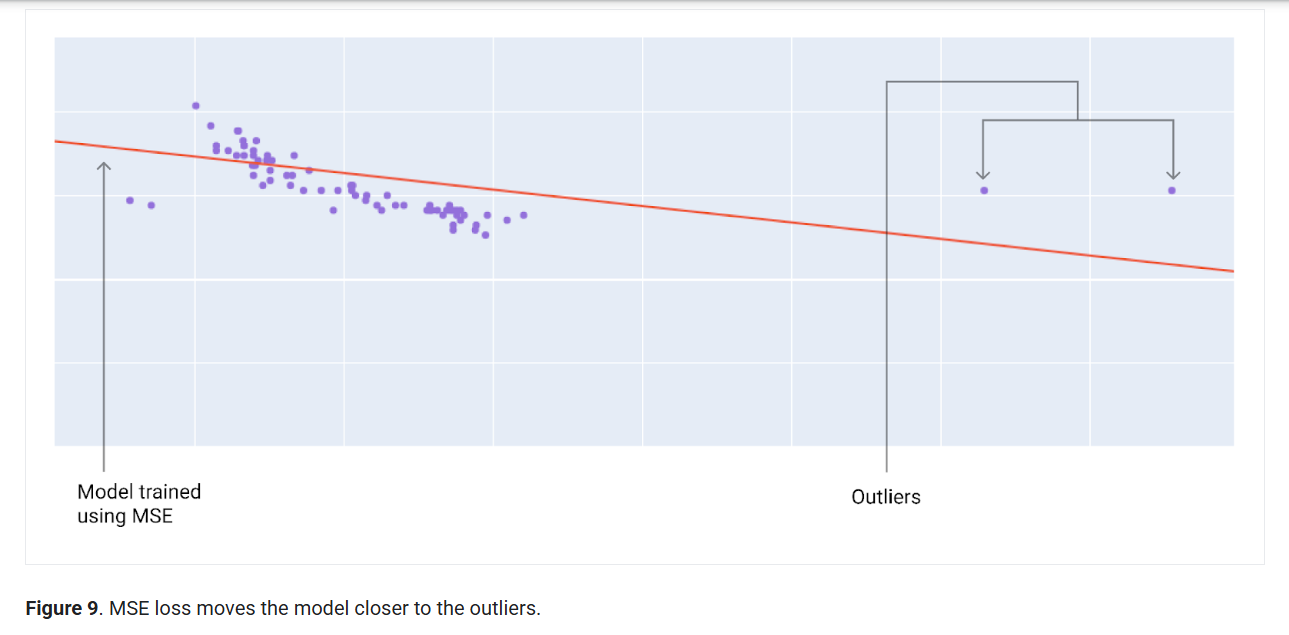

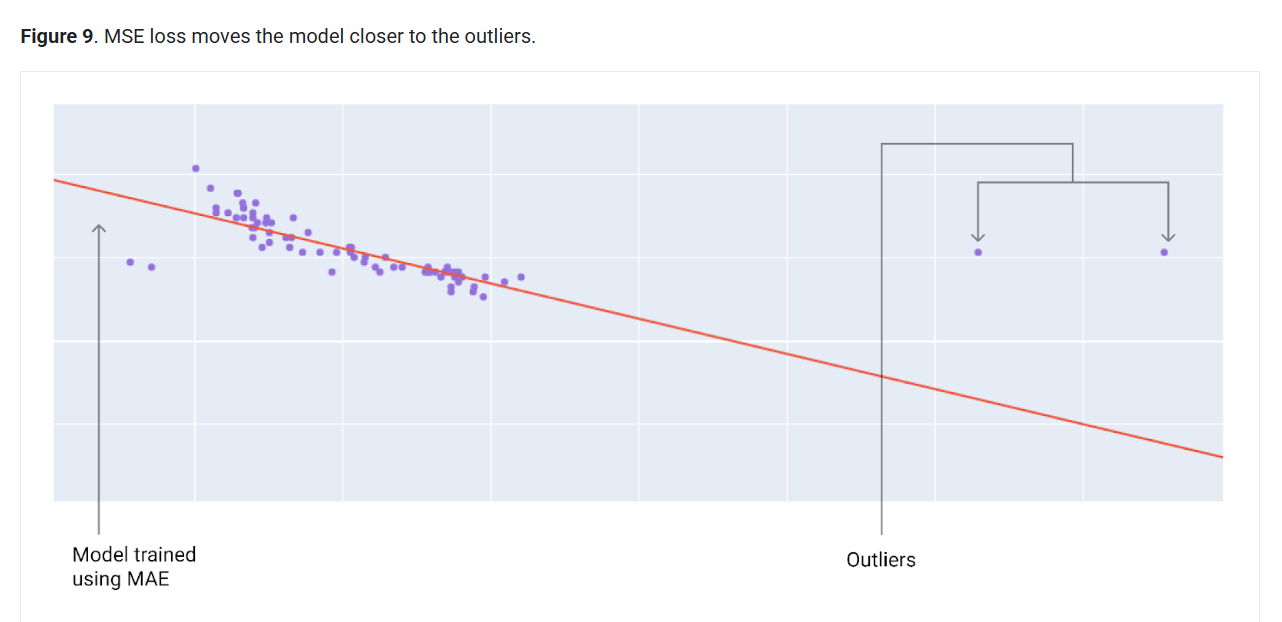

##  The mathematical properties of MSE often make optimization smoother. Root Mean Squared Error (RMSE) is often used to get the error back into the same units as the label.

## GRDIENT DESCENT 

The model begins training with randomized weights and biases near zero, and then repeats the following steps:

Calculate the loss with the current weight and bias.

Determine the direction to move the weights and bias that reduce loss.

Move the weight and bias values a small amount in the direction that reduces loss.

Return to step one and repeat the process until the model can't reduce the loss any further.

You can see that the loss gets lower with each updated weight and bias. In this example, we stopped after six iterations. In practice, a model trains until it converges. When a model converges, additional iterations don't reduce loss more because gradient descent has found the weights and bias that nearly minimize the loss.

If the model continues to train past convergence, loss begins to fluctuate in small amounts as the model continually updates the parameters around their lowest values. This can make it hard to verify that the model has actually converged. To confirm the model has converged, you'll want to continue training until the loss has stabilized.

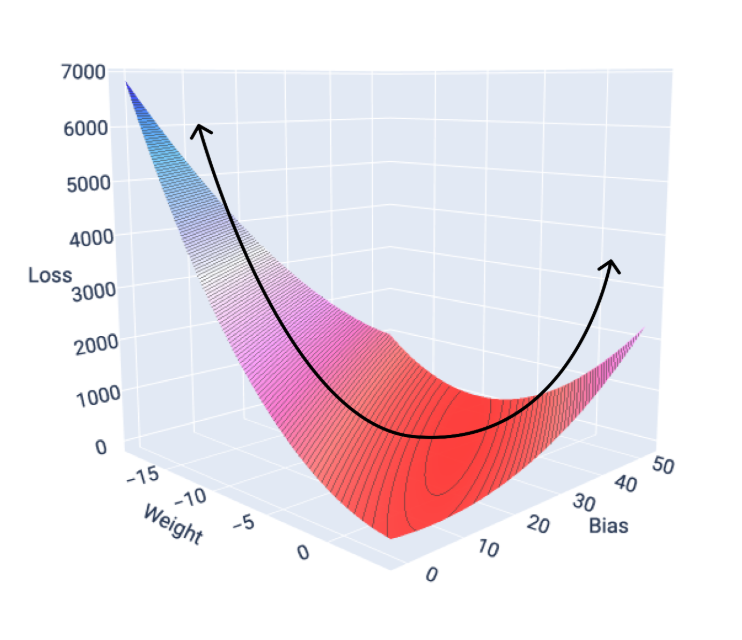

Figure 16. Loss surface that shows its convex shape.

In this example, a weight of -5.44 and bias of 35.94 produce the lowest loss at 5.54:

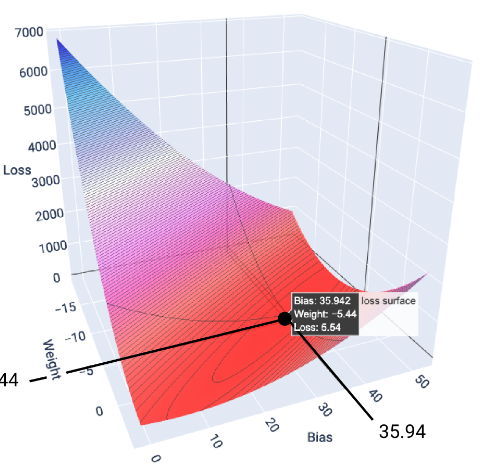

A linear model converges when it's found the minimum loss. If we graphed the weights and bias points during gradient descent, the points would look like a ball rolling down a hill, finally stopping at the point where there's no more downward slope.

## Note: The model almost never finds the exact weight and bias values that minimize loss, but instead finds values very close to them.


## Note: This point represents the minimum loss for the model, which is typically greater than 0. A loss of 0 would mean that the model fits every data point exactly, which is usually a sign of overfitting (i.e., the model is too complex/powerful). Overfitting is discussed in more depth later in the course.

In [1]:
# making linear regression 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
import ml_edu.experiment
import ml_edu.results


taxi_data = pd.read_csv(r'C:\Users\Dhruv stark\Desktop\machine learning practice\Taxi_Trips_-_2024_20240408.csv')

taxi_data.columns 

train_df = taxi_data.loc[:,('Trip Miles', 'Trip Seconds', 'Fare', 'Company', 'Payment Type', 'Tips')]
train_df.head(20)

ModuleNotFoundError: No module named 'plotly'

In [ ]:
print('total no of row {0}\n\n'.format(len(train_df.index)))
# OR USE 

train_df.shape

In [ ]:
train_df.describe().T

In [ ]:
max_fare = train_df['Fare'].max()
max_fare

min_fare=train_df['Trip Miles'].mean()
min_fare

num_unique_compaines =train_df["Company"].nunique()

num_unique_compaines

most = train_df['Payment Type'].value_counts()
most








In [ ]:
train_df.corr(numeric_only = True)

In [2]:
#@title Code - Define ML functions

def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model


def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.
